# Reorder points from any source

**Where do the reorder point `s` and the order-up-to level `S` come from?** In practice, anywhere: one company-wide rule, a planning table, a demand forecast, or a formula a team has used for years. This notebook runs a small café with three products and gives the same `ReorderPointPolicy` its levels in every one of those ways. At the end we replay all of them on the same demand and compare them.

The rule itself never changes. At each review, if the **inventory position** (on hand plus on order minus backlog) is at or below `s`, the policy orders up to `S`, or a fixed `Q` for an `(s,Q)` policy. Only the source of `s` and `S` changes:

| What you have | How you pass it to `fit` |
|---|---|
| one pair for every SKU | `reorder_point=20.0, order_up_to_level=50.0` |
| one value per SKU | a dict, or a Series indexed by SKU such as `table['s']` |
| a dated forecast quantile | `target_df` with `reorder_point_column=...`, `forecast_origin`, `forecast_frequency` |
| your own rule | `target_df` with `target_provider=YourProvider()` |

[Notebook 05b](05b_reorder_points_and_review_frequency.ipynb) explains how review timing sets the window a reorder point must cover. Here we focus on the sources.

## 1. One café, one shared scenario

Three products with different daily demand rates: espresso beans sell about 9 units a day, oat milk 5, and chai syrup 1.5. Deliveries take **two days**, and the buyer reviews stock **every three days**. We replay eight weeks of Poisson demand; the first week is warm-up and the remaining seven weeks are scored.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stockcast import (
    InventoryStateDataFrame, ReorderPointPolicy, ReorderPointTargetProvider,
    ReorderPointTargets, SimulationEngine,
)
from stockcast.evaluation import (
    InventoryEvaluator, avg_on_hand, fill_rate, sku_order_line_count, total_cost,
    validate_event_frame,
)

In [2]:
opening_date = pd.Timestamp('2026-01-05')
rates = {'espresso_beans': 9.0, 'oat_milk': 5.0, 'chai_syrup': 1.5}
skus = list(rates)
lead_days, review_days = 2, 3
days, warmup_days = 56, 7

rng = np.random.default_rng(11)
dates = pd.date_range(opening_date + pd.Timedelta(days=1), periods=days, freq='D')
demand = pd.DataFrame([
    {'unique_id': sku, 'period': period, 'date': date, 'y': float(rng.poisson(rate))}
    for sku, rate in rates.items() for period, date in enumerate(dates)
])
print(demand.groupby('unique_id', sort=False)['y'].agg(['mean', 'max']).round(2))

                mean   max
unique_id                 
espresso_beans  8.62  13.0
oat_milk        4.64  10.0
chai_syrup      1.62   5.0


Every policy below starts from the same opening stock: what is on the shelf on the opening date, with nothing on order and no backlog.

In [3]:
opening = InventoryStateDataFrame.from_observed(
    pd.DataFrame({'unique_id': skus, 'on_hand': [40.0, 25.0, 8.0]}),
    start_date=opening_date,
)
print(opening.inventory_position()[['unique_id', 'on_hand', 'inventory_position']]
      .to_string(index=False))

     unique_id  on_hand  inventory_position
espresso_beans     40.0                40.0
      oat_milk     25.0                25.0
    chai_syrup      8.0                 8.0


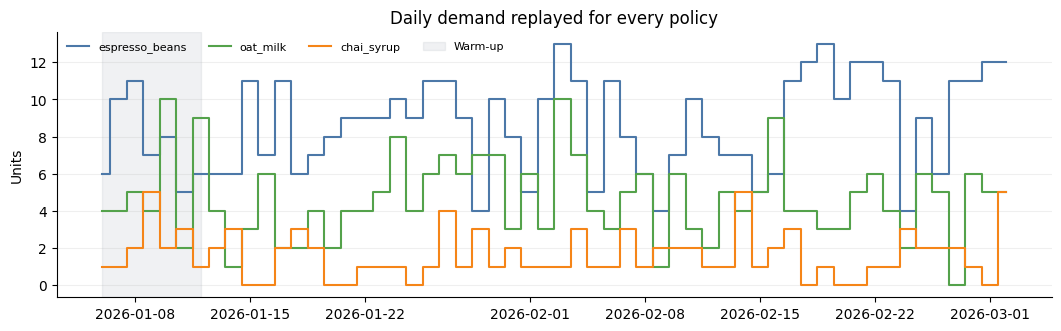

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 3.2), layout='constrained')
for sku, color in zip(skus, ['#4C78A8', '#54A24B', '#F58518']):
    series = demand.loc[demand.unique_id.eq(sku)]
    ax.step(series.date, series.y, where='mid', color=color, label=sku)
ax.axvspan(dates[0], dates[warmup_days - 1], color='#9CA3AF', alpha=.15, label='Warm-up')
ax.set(title='Daily demand replayed for every policy', ylabel='Units')
ax.legend(frameon=False, fontsize=8, ncol=4)
ax.grid(axis='y', alpha=.2)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

## 2. One pair for every SKU

The simplest source is a single house rule: *reorder at 20, fill up to 50*. Pass the two numbers to `fit`. With no table of SKUs, the pair applies to every SKU the run meets.

We call `predict()` once on the opening state to see the decision. It returns a request only; it does not change the state.

In [5]:
one_pair = ReorderPointPolicy(
    lead_time=lead_days, review_period=review_days, allow_backorders=False,
).fit(reorder_point=20.0, order_up_to_level=50.0)

decision = one_pair.predict(opening, current_period=0).get_dataframe()
print(decision[['unique_id', 'inventory_position', 'reorder_point', 'target_level',
                'order_quantity']].to_string(index=False))
assert decision.order_quantity.tolist() == [0.0, 0.0, 42.0]

     unique_id  inventory_position  reorder_point  target_level  order_quantity
espresso_beans                40.0           20.0          50.0             0.0
      oat_milk                25.0           20.0          50.0             0.0
    chai_syrup                 8.0           20.0          50.0            42.0


Only chai syrup is at or below 20, so only chai orders: 42 units, enough for about four weeks of its demand. Espresso beans, which sell six times faster, wait with 40 units. One pair for very different products is easy to state, but it rarely fits all of them. We will see the cost of that in section 7.

The policy records where its levels came from. A single pair has no per-SKU table, so `get_parameters()` explains how to get one instead of inventing it:

In [6]:
print(one_pair.get_target_metadata())
try:
    one_pair.get_parameters()
except ValueError as error:
    print('ValueError:', error)

{'representation': 'fixed_policy_levels', 'target_probability': None, 'target_source': 'external_direct', 'forecast_origin': None, 'forecast_frequency': None, 'order_up_to_representation': 'external_policy_level'}
ValueError: the reorder point is one value for every SKU (s=20.0, S=50.0); pass target_df to fit for a per-SKU table


## 3. One value per SKU: a dict or a planning table

Most planners keep a table with one `s` and one `S` per product. Pass the columns as Series indexed by SKU, or write them as dicts. Both give the same policy.

In [7]:
plan = pd.DataFrame({
    'unique_id': skus,
    's': [35.0, 20.0, 6.0],
    'S': [75.0, 45.0, 14.0],
}).set_index('unique_id')

planner_table = ReorderPointPolicy(
    lead_time=lead_days, review_period=review_days, allow_backorders=False,
).fit(reorder_point=plan['s'], order_up_to_level=plan['S'])

planner_dict = ReorderPointPolicy(
    lead_time=lead_days, review_period=review_days, allow_backorders=False,
).fit(
    reorder_point={'espresso_beans': 35.0, 'oat_milk': 20.0, 'chai_syrup': 6.0},
    order_up_to_level={'espresso_beans': 75.0, 'oat_milk': 45.0, 'chai_syrup': 14.0},
)
pd.testing.assert_frame_equal(planner_table.get_parameters(), planner_dict.get_parameters())
print(planner_table.get_parameters().to_string(index=False))

     unique_id  reorder_point  order_up_to_level
espresso_beans           35.0               75.0
      oat_milk           20.0               45.0
    chai_syrup            6.0               14.0


Stockcast checks the values before any run: every number is finite, `s ≥ 0`, `S ≥ s`, and `s` and `S` name the same SKUs. A swapped pair fails right away instead of producing strange orders later:

In [8]:
try:
    ReorderPointPolicy(
        lead_time=lead_days, review_period=review_days, allow_backorders=False,
    ).fit(reorder_point=plan['S'], order_up_to_level=plan['s'])
except ValueError as error:
    print('ValueError:', error)

ValueError: order-up-to levels must be greater than or equal to reorder points


### The same table as an `(s,Q)` policy

Some products arrive in fixed lots: a pallet, a case, a minimum order. Give `order_quantity` to the constructor and the policy becomes `(s,Q)`: it orders exactly `Q` when the position is at or below `s`. It then needs `s` only.

In [9]:
fixed_lot = ReorderPointPolicy(
    lead_time=lead_days, review_period=review_days, order_quantity=30.0,
    allow_backorders=False,
).fit(reorder_point=plan['s'])
print(fixed_lot.policy_type)
print(fixed_lot.get_parameters().to_string(index=False))

sQ
     unique_id  reorder_point  order_quantity
espresso_beans           35.0            30.0
      oat_milk           20.0            30.0
    chai_syrup            6.0            30.0


## 4. A dated forecast quantile

A forecast gives `s` a meaning: *the 95% quantile of demand over the window this decision must cover*. With a two-day lead time and a review every three days, an order skipped today can next be placed in three days and arrives two days after that, so `s` must cover **`H = L + R = 5` days** of demand.

Here the forecast is the known Poisson rate. We simulate total demand over five days and take its 95% quantile; we never add up daily quantiles. `S` adds one review period of mean demand on top. It is a planning choice, not a quantile.

In [10]:
horizon = lead_days + review_days
paths = np.random.default_rng(0)


def window_quantile(rate, probability=0.95):
    totals = paths.poisson(rate, size=(20_000, horizon)).sum(axis=1)
    return float(np.quantile(totals, probability))


forecast_targets = pd.DataFrame({
    'unique_id': skus,
    's_q95': [window_quantile(rate) for rate in rates.values()],
    'end': opening_date + pd.Timedelta(days=horizon),
})
forecast_targets['S'] = forecast_targets['s_q95'] + [review_days * r for r in rates.values()]
print(forecast_targets.to_string(index=False))

     unique_id  s_q95        end    S
espresso_beans   56.0 2026-01-10 83.0
      oat_milk   33.0 2026-01-10 48.0
    chai_syrup   12.0 2026-01-10 16.5


Forecast targets are **dated**. `forecast_origin` is the last date whose demand the forecast knew, `forecast_frequency` is the length of one period, and the optional `end` column is the last date `s` covers. `service_level=0.95` states that `s` is a 95% quantile. The policy checks that this window matches its own `L + R` and records all of it.

In [11]:
from_forecast = ReorderPointPolicy(
    lead_time=lead_days, review_period=review_days, service_level=0.95,
    allow_backorders=False,
).fit(
    forecast_targets, reorder_point_column='s_q95', order_up_to_column='S',
    forecast_origin=opening_date, forecast_frequency='D',
    reorder_end_date_column='end',
)
print(from_forecast.get_parameters().to_string(index=False))
print(from_forecast.get_target_metadata())

     unique_id  reorder_point  order_up_to_level
espresso_beans           56.0               83.0
      oat_milk           33.0               48.0
    chai_syrup           12.0               16.5
{'representation': 'direct_reorder_point_target', 'target_probability': 0.95, 'reorder_horizon': 5, 'target_source': 'external_direct', 'forecast_origin': '2026-01-05T00:00:00', 'forecast_frequency': 'D', 'reorder_end_date': '2026-01-10T00:00:00', 'order_up_to_representation': 'external_policy_level'}


A forecast that covers the wrong window is refused. Here the `end` date covers only the two lead-time days:

In [12]:
lead_time_only = forecast_targets.assign(end=opening_date + pd.Timedelta(days=lead_days))
try:
    ReorderPointPolicy(
        lead_time=lead_days, review_period=review_days, service_level=0.95,
        allow_backorders=False,
    ).fit(
        lead_time_only, reorder_point_column='s_q95', order_up_to_column='S',
        forecast_origin=opening_date, forecast_frequency='D',
        reorder_end_date_column='end',
    )
except ValueError as error:
    print('ValueError:', error)

ValueError: target_df.end must equal 2026-01-10 00:00:00 for horizon 5; got ['2026-01-07 00:00:00']


If your `s` column comes from a forecast but is **not** a quantile at a stated probability, for example an optimised `(s,S)` pair, keep the same call and set `service_level=None`. The window is still checked, but no probability is claimed.

## 5. Your own rule: a target provider

Many teams have a rule of their own. This café uses **days of cover**: reorder when stock covers fewer than 4 days of the recent sales rate, and fill up to 9 days. A `ReorderPointTargetProvider` packages such a rule: `provide()` receives the table passed to `fit` and returns one row per SKU.

In [13]:
class DaysOfCover(ReorderPointTargetProvider):
    # s = reorder_days x daily rate and S = order_up_to_days x daily rate,
    # rounded up to whole units.

    def __init__(self, reorder_days, order_up_to_days):
        self.reorder_days = reorder_days
        self.order_up_to_days = order_up_to_days

    def provide(self, target_data, *, sku_column):
        rate = target_data['daily_rate']
        frame = pd.DataFrame({
            sku_column: target_data[sku_column],
            'reorder_point': np.ceil(self.reorder_days * rate),
            'order_up_to_level': np.ceil(self.order_up_to_days * rate),
        })
        return ReorderPointTargets(frame=frame, metadata={'rate_window_days': 28})

    def to_manifest(self):
        return {**super().to_manifest(), 'reorder_days': self.reorder_days,
                'order_up_to_days': self.order_up_to_days}

The rates below stand in for the trailing 28-day sales average the café would compute from its history. Stockcast validates the provider's output with the same checks as fixed values.

In [14]:
history_rates = pd.DataFrame({'unique_id': skus, 'daily_rate': [8.6, 5.3, 1.4]})
days_of_cover = ReorderPointPolicy(
    lead_time=lead_days, review_period=review_days, allow_backorders=False,
).fit(history_rates, target_provider=DaysOfCover(reorder_days=4, order_up_to_days=9))
print(days_of_cover.get_parameters().to_string(index=False))
print(days_of_cover.get_target_metadata()['provider'])

     unique_id  reorder_point  order_up_to_level
espresso_beans           35.0               78.0
      oat_milk           22.0               48.0
    chai_syrup            6.0               13.0
{'provider_class': 'DaysOfCover', 'target_source': 'custom_provider', 'reorder_days': 4, 'order_up_to_days': 9}


## 6. Dates are optional for fixed values and providers

Fixed values and provider levels do not describe a forecast window, so dates are optional. A policy without dates records none. When it runs on dated demand, state the length of one period with `period_frequency`; Stockcast does not guess it.

In [15]:
undated_run = SimulationEngine().run(
    planner_table, demand, opening, period_frequency='D',
)
validate_event_frame(undated_run.to_event_frame())
print(undated_run.run_manifest['policy']['target_metadata'])

{'representation': 'fixed_policy_levels', 'target_probability': None, 'target_source': 'external_direct', 'forecast_origin': None, 'forecast_frequency': None, 'order_up_to_representation': 'external_policy_level'}


When you do date them, the run checks the date. Suppose the planning table was built a week **after** the opening date, with sales the simulation has not seen yet. Replaying it from the opening date would use future information, so the run refuses:

In [16]:
planned_later = ReorderPointPolicy(
    lead_time=lead_days, review_period=review_days, allow_backorders=False,
).fit(
    reorder_point=plan['s'], order_up_to_level=plan['S'],
    forecast_origin=opening_date + pd.Timedelta(days=7), forecast_frequency='D',
)
try:
    SimulationEngine().run(planned_later, demand, opening)
except ValueError as error:
    print('ValueError:', error)

ValueError: policy forecast_origin 2026-01-12 00:00:00 must not be after decision information date 2026-01-05 00:00:00


## 7. Compare every source on the same demand

`run_comparison` accepts `{label: policy}`. Every branch gets the same demand, its own copy of the opening stock, and the same warm-up and scoring windows, so the policies differ only in where their levels came from.

In [17]:
policies = {
    'One pair for all': one_pair,
    'Planner table': planner_table,
    '(s,Q) Q=30': fixed_lot,
    'Forecast 95%': from_forecast,
    'Days of cover': days_of_cover,
}
comparison = SimulationEngine().run_comparison(
    policies, demand, opening, period_frequency='D', warmup_periods=warmup_days,
)

Every branch is scored with the same declared costs: 0.05 per unit held per day, 2.00 per unit of lost sales, and 4.00 per order line.

In [18]:
costs = {
    'holding_cost_per_unit_period': 0.05,
    'shortage_cost_per_unit': 2.0,
    'order_cost_per_sku_line': 4.0,
    'order_cost_per_unit': 0.0,
    'cost_components': ['holding', 'shortage', 'ordering'],
}
scores = pd.concat({
    label: InventoryEvaluator().fit(comparison[label]).evaluate(
        [fill_rate, avg_on_hand, sku_order_line_count, total_cost],
        context=costs,
    )
    for label in comparison
}).droplevel(1)
print(scores.round(3).to_string())

                  fill_rate  avg_on_hand  sku_order_line_count  total_cost
One pair for all      0.890       21.116                    16     379.200
Planner table         0.977       17.701                    22     252.100
(s,Q) Q=30            0.953       16.272                    22     275.600
Forecast 95%          0.999       24.745                    31     306.875
Days of cover         0.997       18.088                    21     220.950


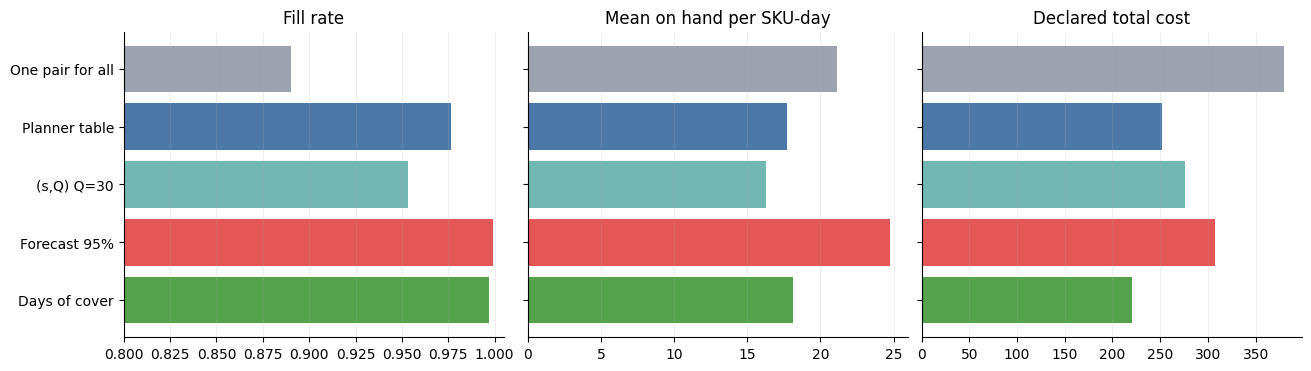

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout='constrained')
colors = ['#9CA3AF', '#4C78A8', '#72B7B2', '#E45756', '#54A24B']
for ax, column, title in [
    (axes[0], 'fill_rate', 'Fill rate'),
    (axes[1], 'avg_on_hand', 'Mean on hand per SKU-day'),
    (axes[2], 'total_cost', 'Declared total cost'),
]:
    ax.barh(scores.index, scores[column], color=colors)
    ax.set(title=title)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=.2)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_xlim(.8, 1.005)  # Zoom only this near-one measure.
for ax in axes[1:]:
    ax.set_yticklabels([])
plt.show()

The single pair is the worst on both service and cost: it is far too low for espresso beans and far too high for chai syrup. The per-SKU sources all do better. The forecast quantile gives the highest fill rate but holds the most stock. Days of cover nearly matches its service with less stock and the lowest cost. The planner table and the fixed lot hold the least stock but lose more sales. These rankings belong to this replay and these costs; with other rates the balance moves, which is exactly what a comparison is for.

The per-SKU view shows *where* the single pair goes wrong:

In [20]:
per_sku = pd.concat({
    label: InventoryEvaluator().fit(comparison[label]).evaluate(
        [fill_rate, avg_on_hand], groupby=['unique_id'],
    ).set_index('unique_id')
    for label in ['One pair for all', 'Days of cover']
})
print(per_sku.round(3).to_string())

                                 fill_rate  avg_on_hand
                 unique_id                             
One pair for all espresso_beans      0.819       14.122
                 oat_milk            0.991       20.755
                 chai_syrup          1.000       28.469
Days of cover    espresso_beans      1.000       28.367
                 oat_milk            1.000       20.673
                 chai_syrup          0.974        5.224


### Follow one product through its levels

Finally, the event ledger shows the rule at work. For espresso beans under the days-of-cover policy, every third day is a review: the position before it (white dots) is compared with `s`, and each order (orange) lifts the position back to `S`. Demand then pulls the position down until the next review.

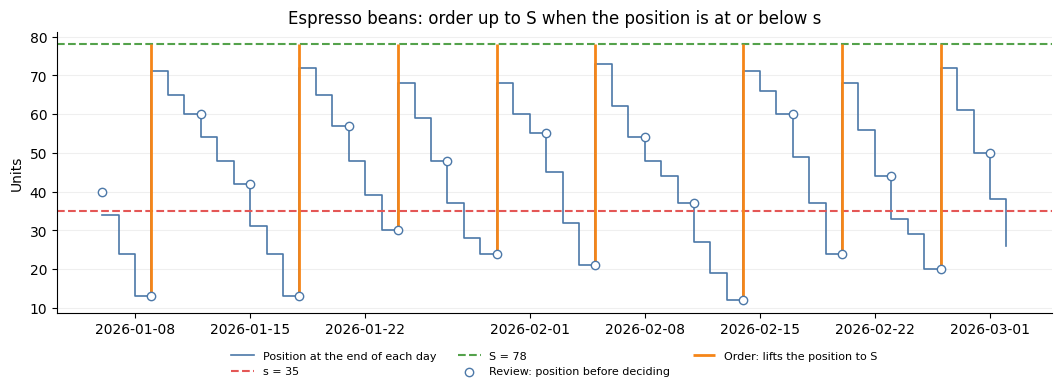

In [21]:
events = validate_event_frame(comparison['Days of cover'].to_event_frame())
beans = events.loc[events.event_type.eq('period') & events.unique_id.eq('espresso_beans')]
levels = days_of_cover.get_parameters().set_index('unique_id').loc['espresso_beans']
reviews = beans.loc[beans.is_review_period]
ordered = reviews.loc[reviews.order_quantity.gt(0)]

fig, ax = plt.subplots(figsize=(10.5, 3.8), layout='constrained')
ax.step(beans.date, beans.inventory_position_end, where='post', color='#4C78A8',
        linewidth=1.2, label='Position at the end of each day')
ax.axhline(levels.reorder_point, color='#E45756', linestyle='--',
           label=f's = {levels.reorder_point:.0f}')
ax.axhline(levels.order_up_to_level, color='#54A24B', linestyle='--',
           label=f'S = {levels.order_up_to_level:.0f}')
ax.scatter(reviews.date, reviews.decision_inventory_position, facecolor='white',
           edgecolor='#4C78A8', zorder=3, label='Review: position before deciding')
ax.vlines(ordered.date, ordered.decision_inventory_position,
          ordered.decision_inventory_position + ordered.order_quantity,
          color='#F58518', linewidth=2, label='Order: lifts the position to S')
ax.set(title='Espresso beans: order up to S when the position is at or below s',
       ylabel='Units')
ax.legend(frameon=False, fontsize=8, ncol=3, loc='upper center', bbox_to_anchor=(.5, -.1))
ax.grid(axis='y', alpha=.2)
ax.spines[['top', 'right']].set_visible(False)
plt.show()
assert (ordered.decision_inventory_position <= levels.reorder_point).all()
assert np.allclose(ordered.decision_inventory_position + ordered.order_quantity,
                   levels.order_up_to_level)

## What to carry into your own work

1. **One policy, many sources.** `ReorderPointPolicy.fit` takes exactly one source: fixed values (`reorder_point=`), dated forecast columns (`reorder_point_column=`), or your own rule (`target_provider=`). The ordering rule is the same for all of them.
2. **Fixed values come in three shapes:** one number for every SKU, a dict, or a Series indexed by SKU, such as a column of your planning table.
3. **Forecast targets are dated and checked.** State the origin and frequency, and use `service_level` only when `s` really is a quantile over the `L + R` window; otherwise set `service_level=None`.
4. **A provider keeps your rule and its settings together**, and its `to_manifest()` output travels with every result.
5. **Compare sources on shared demand and declared costs** before choosing one. The best source depends on your products and your costs.

[Notebook 05b](05b_reorder_points_and_review_frequency.ipynb) goes deeper into review timing and the `L + R` window. [Notebook 04f](04f_scheduled_forecast_simulation.ipynb) refreshes dated forecast targets on a schedule. [Notebook 06](06_fair_forecast_and_policy_comparisons.ipynb) builds fair forecast and policy comparisons.